# Task 2: Support Vector Machine (SVM) Classification using Real-world Dataset
Implementing a Support Vector Machine (SVM) model on a Telecom Churn Dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

### 1. Load Dataset from Project Directory

In [2]:
df = pd.read_csv('churn-bigml-80.csv')
print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (2666, 20)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


### 2. Preprocessing
The dataset contains categorical and boolean values. We will encode them, separate features, scale them, and finally apply PCA to reduce dimensions to 2 so that we can clearly visualize our Decision Boundary mappings.

In [3]:
# Drop non-predictive categorical string columns for simplicity
if 'State' in df.columns:
    df = df.drop(['State'], axis=1)

# Encode Boolean/Categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include=['object', 'bool']).columns:
    df[col] = le.fit_transform(df[col])

# Separate Features (X) and Target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Support Vector Machines heavily rely on scaled features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reduce dimensions to 2 using PCA for 2D boundary visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("PCA completed. Dimension reduced to 2 for graphical visualization.")

PCA completed. Dimension reduced to 2 for graphical visualization.


### 3. Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)
print(f"Training Data points: {X_train.shape[0]}")
print(f"Testing Data points: {X_test.shape[0]}")

Training Data points: 1866
Testing Data points: 800


### 4. Model Training (Linear vs RBF Kernel)

In [5]:
svm_linear = SVC(kernel='linear', probability=True, random_state=42)
svm_linear.fit(X_train, y_train)

svm_rbf = SVC(kernel='rbf', probability=True, random_state=42)
svm_rbf.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


### 5. Evaluate Models (Accuracy, Precision, Recall, AUC)

In [6]:
def evaluate_model(y_true, y_pred, y_prob, model_name):
    print(f"--- Evaluation Metrics for {model_name} ---")
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"AUC:       {auc:.4f}\n")

# Linear Predictions
y_pred_linear = svm_linear.predict(X_test)
y_prob_linear = svm_linear.predict_proba(X_test)[:, 1]
evaluate_model(y_test, y_pred_linear, y_prob_linear, "SVM (Linear Kernel)")

# RBF Predictions
y_pred_rbf = svm_rbf.predict(X_test)
y_prob_rbf = svm_rbf.predict_proba(X_test)[:, 1]
evaluate_model(y_test, y_pred_rbf, y_prob_rbf, "SVM (RBF Kernel)")

--- Evaluation Metrics for SVM (Linear Kernel) ---
Accuracy:  0.8538
Precision: 0.0000
Recall:    0.0000
AUC:       0.4944

--- Evaluation Metrics for SVM (RBF Kernel) ---
Accuracy:  0.8538
Precision: 0.0000
Recall:    0.0000
AUC:       0.5726



### 6. Visualizing Decision Boundaries and Statistics

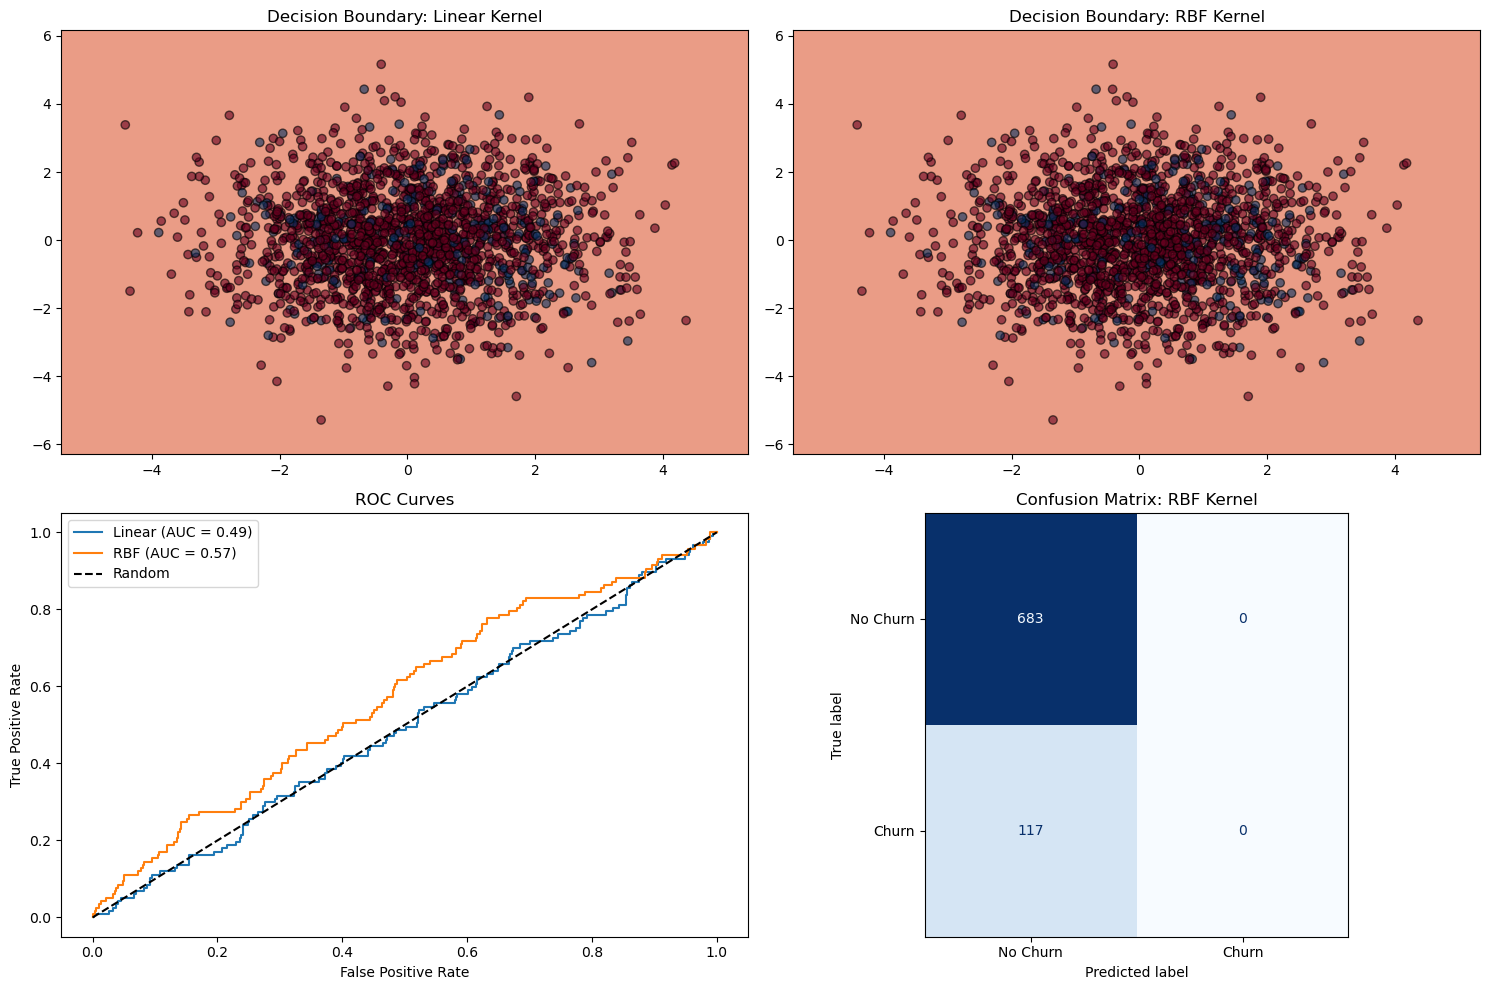

In [7]:
def plot_decision_boundary(clf, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    h = 0.05
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, edgecolors='k', alpha=0.6)
    plt.title(title)

plt.figure(figsize=(15, 10))

# Decision Boundary for Linear
plt.subplot(2, 2, 1)
plot_decision_boundary(svm_linear, X_train, y_train, "Decision Boundary: Linear Kernel")

# Decision Boundary for RBF
plt.subplot(2, 2, 2)
plot_decision_boundary(svm_rbf, X_train, y_train, "Decision Boundary: RBF Kernel")

# ROC Curves
plt.subplot(2, 2, 3)
fpr_linear, tpr_linear, _ = roc_curve(y_test, y_prob_linear)
fpr_rbf, tpr_rbf, _ = roc_curve(y_test, y_prob_rbf)
plt.plot(fpr_linear, tpr_linear, label=f'Linear (AUC = {roc_auc_score(y_test, y_prob_linear):.2f})')
plt.plot(fpr_rbf, tpr_rbf, label=f'RBF (AUC = {roc_auc_score(y_test, y_prob_rbf):.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()

# Confusion Matrix (RBF)
plt.subplot(2, 2, 4)
cm = confusion_matrix(y_test, y_pred_rbf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(ax=plt.gca(), cmap='Blues', colorbar=False)
plt.title("Confusion Matrix: RBF Kernel")

plt.tight_layout()
plt.show()